# Notebook 09 · Geometrías base territoriales de Iberia

En este notebook preparamos la base geográfica común del TFB.

Trabajamos con las 22 regiones NUTS 2 de España peninsular y Portugal continental y mantenemos Andorra como unidad nacional complementaria.

Generamos las geometrías territoriales y calculamos áreas y centroides usando EPSG:4326 y EPSG:3035.

Estas salidas servirán como referencia territorial para integrar en el Notebook 10 los resultados obtenidos en los notebooks anteriores.

En este notebook no calculamos la idoneidad final, sino que preparamos y validamos la estructura territorial común del proyecto.


In [1]:
# instalamos librerias
%pip install -q pyogrio

Note: you may need to restart the kernel to use updated packages.


## Fuentes geográficas

Usamos GISCO/Eurostat para las 22 regiones NUTS 2 de España peninsular y Portugal continental, y Natural Earth para la geometría nacional de Andorra.

Primero comprobamos si los archivos están disponibles en Kaggle. Si no lo están, recurrimos a las fuentes originales.

Mantenemos Andorra como unidad nacional complementaria y no como una región NUTS 2 comparable.

In [2]:
# configuración 
import shutil
import zipfile
from pathlib import Path

import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.validation import make_valid

NOMBRE_NOTEBOOK = "09 - Geometrías base territoriales de Iberia"
NOMBRE_BLOQUE = "09_geometrias_base_territoriales_iberia"
AMBITO_ESTUDIO = "España peninsular, Portugal continental y Andorra"

CRS_GEOGRAFICO = "EPSG:4326"
CRS_PROYECTADO = "EPSG:3035"

INPUT_DIR = Path("/kaggle/input")
BASE_DIR = Path("/kaggle/working") / NOMBRE_BLOQUE

RAW_GISCO_DIR = BASE_DIR / "raw/gisco_eurostat"
RAW_NATURAL_EARTH_DIR = BASE_DIR / "raw/natural_earth"
PROCESSED_DIR = BASE_DIR / "processed"
GPKG_DIR = BASE_DIR / "gpkg"
FIGURAS_DIR = BASE_DIR / "figuras"
DASHBOARD_DIR = BASE_DIR / "dashboard"
LOGS_DIR = BASE_DIR / "logs"
MANIFEST_DIR = BASE_DIR / "manifest"

carpetas_salida = [
    RAW_GISCO_DIR,
    RAW_NATURAL_EARTH_DIR,
    PROCESSED_DIR,
    GPKG_DIR,
    FIGURAS_DIR,
    DASHBOARD_DIR,
    LOGS_DIR,
    MANIFEST_DIR
]

for carpeta in carpetas_salida:
    carpeta.mkdir(parents=True, exist_ok=True)

PAISES_NUTS_COMPARABLES_09 = ["ES", "PT"]
CODIGO_ANDORRA_09 = "AD"

CODIGOS_NUTS_EXCLUIDOS_MODELO_09 = [
    "ES53", "ES63", "ES64", "ES70",
    "PT20", "PT30"
]

configuracion = pd.DataFrame([{
    "notebook": NOMBRE_NOTEBOOK,
    "ambito": AMBITO_ESTUDIO,
    "crs_geografico": CRS_GEOGRAFICO,
    "crs_proyectado": CRS_PROYECTADO
}])
configuracion.to_csv(
    MANIFEST_DIR / "configuracion_inicial_notebook_09.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Notebook:", NOMBRE_NOTEBOOK)
print("Ámbito:", AMBITO_ESTUDIO)
print("Carpeta de trabajo:", BASE_DIR)


Notebook: 09 - Geometrías base territoriales de Iberia
Ámbito: España peninsular, Portugal continental y Andorra
Carpeta de trabajo: /kaggle/working/09_geometrias_base_territoriales_iberia


In [3]:
# datos preparados en Kaggle 

# GISCO; regiones NUTS 2
nombre_nuts_01c = "NUTS_RG_20M_2024_4326_LEVL_2.geojson"
ruta_nuts_input_01c = next(
    INPUT_DIR.rglob(nombre_nuts_01c),
    None
)

if ruta_nuts_input_01c is not None:
    shutil.copy2(
        ruta_nuts_input_01c,
        RAW_GISCO_DIR / nombre_nuts_01c
    )
    origen_nuts_01c = "Kaggle Input"
else:
    origen_nuts_01c = "Fuente original"

# Natural Earth; geometría de Andorra
ruta_zip_ne_01c = next(
    INPUT_DIR.rglob("ne_10m_admin_0_countries.zip"),
    None
)
ruta_shp_ne_01c = next(
    INPUT_DIR.rglob("ne_10m_admin_0_countries.shp"),
    None
)

if ruta_zip_ne_01c is not None:
    shutil.copy2(
        ruta_zip_ne_01c,
        RAW_NATURAL_EARTH_DIR / ruta_zip_ne_01c.name
    )
    origen_ne_01c = "Kaggle Input (ZIP)"
elif ruta_shp_ne_01c is not None:
    for archivo in ruta_shp_ne_01c.parent.glob(
        "ne_10m_admin_0_countries.*"
    ):
        shutil.copy2(
            archivo,
            RAW_NATURAL_EARTH_DIR / archivo.name
        )
    origen_ne_01c = "Kaggle Input (SHP)"
else:
    origen_ne_01c = "Fuente original"

datos_disponibles_01c = sum([
    origen_nuts_01c.startswith("Kaggle Input"),
    origen_ne_01c.startswith("Kaggle Input")
])

print("GISCO NUTS 2024:", origen_nuts_01c)
print("Natural Earth:", origen_ne_01c)
print(
    "Datos encontrados en Kaggle Input:",
    datos_disponibles_01c,
    "/ 2"
)

GISCO NUTS 2024: Kaggle Input
Natural Earth: Kaggle Input (SHP)
Datos encontrados en Kaggle Input: 2 / 2


In [4]:
# fuentes y criterios utilizados
df_fuentes_geometricas_09 = pd.DataFrame([
    {
        "fuente": "GISCO / Eurostat",
        "uso": "22 regiones NUTS 2 de España y Portugal",
        "origen": origen_nuts_01c
    },
    {
        "fuente": "Natural Earth",
        "uso": "Geometría nacional de Andorra",
        "origen": origen_ne_01c
    }
])
df_decisiones_metodologicas_09 = pd.DataFrame({
    "criterio": [
        "Usamos NUTS 2024 y excluimos los territorios no peninsulares",
        "Mantenemos Andorra como unidad nacional complementaria",
        "Utilizamos codigo_geo como identificador territorial común",
        "Trabajamos con EPSG:4326 y EPSG:3035"
    ]
})
archivos_02a = {
    "fuentes_geometricas_notebook_09.csv": df_fuentes_geometricas_09,
    "decisiones_metodologicas_notebook_09.csv": df_decisiones_metodologicas_09
}

for nombre, tabla in archivos_02a.items():
    tabla.to_csv(
        MANIFEST_DIR / nombre,
        index=False,
        encoding="utf-8-sig"
    )

print("Fuentes:", len(df_fuentes_geometricas_09))
print("Criterios metodológicos:", len(df_decisiones_metodologicas_09))


Fuentes: 2
Criterios metodológicos: 4


In [5]:
# Geometrías NUTS 2 de GISCO
nombre_nuts_03a = "NUTS_RG_20M_2024_4326_LEVL_2.geojson"
ruta_nuts_03a = RAW_GISCO_DIR / nombre_nuts_03a

if ruta_nuts_03a.exists():
    origen_03a = "Kaggle Input"

else:
    print("El archivo no está en Kaggle Input. Descargando desde GISCO.")
    url_03a = (
        "https://gisco-services.ec.europa.eu/"
        "distribution/v2/nuts/geojson/"
        "NUTS_RG_20M_2024_4326_LEVL_2.geojson"
    )
    respuesta_03a = requests.get(url_03a, timeout=60)
    respuesta_03a.raise_for_status()
    ruta_nuts_03a.write_bytes(respuesta_03a.content)
    origen_03a = "GISCO"

nuts2 = gpd.read_file(ruta_nuts_03a)

columnas_necesarias_03a = [
    "NUTS_ID",
    "NUTS_NAME",
    "CNTR_CODE",
    "geometry"
]

if nuts2.empty:
    raise ValueError("La capa NUTS 2 está vacía.")
if not set(columnas_necesarias_03a).issubset(nuts2.columns):
    raise ValueError("Faltan columnas necesarias en la capa NUTS 2.")

nuts2 = nuts2.to_crs(CRS_GEOGRAFICO)

resumen_03a = pd.DataFrame([{
    "origen": origen_03a,
    "version": 2024,
    "filas": len(nuts2),
    "crs": str(nuts2.crs)
}])
resumen_03a.to_csv(
    MANIFEST_DIR / "CIERRE_03A_gisco_nuts2.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Origen:", origen_03a)
print("Geometrías:", len(nuts2))
print("CRS:", nuts2.crs)


Origen: Kaggle Input
Geometrías: 299
CRS: EPSG:4326


In [6]:
# regiones NUTS 2 comparables
filtro_04a = (
    nuts2["CNTR_CODE"].isin(PAISES_NUTS_COMPARABLES_09)
    & ~nuts2["NUTS_ID"].isin(CODIGOS_NUTS_EXCLUIDOS_MODELO_09)
)

iberia_nuts2_04a = (
    nuts2.loc[
        filtro_04a,
        ["NUTS_ID", "NUTS_NAME", "CNTR_CODE", "geometry"]
    ]
    .rename(columns={
        "NUTS_ID": "codigo_geo",
        "NUTS_NAME": "nombre_territorio",
        "CNTR_CODE": "codigo_pais"
    })
    .copy()
)
iberia_nuts2_04a["nombre_territorio"] = (
    iberia_nuts2_04a["nombre_territorio"].str.strip()
)
iberia_nuts2_04a["pais"] = (
    iberia_nuts2_04a["codigo_pais"]
    .map({"ES": "España", "PT": "Portugal"})
)
iberia_nuts2_04a["escala_territorial"] = "regional_nuts2"
iberia_nuts2_04a["tipo_unidad"] = "nuts2_comparable"
iberia_nuts2_04a["entra_base_geometrica"] = True
iberia_nuts2_04a["entra_ranking_final_directo"] = False
iberia_nuts2_04a["fuente_geometria"] = "GISCO / Eurostat NUTS 2024"
iberia_nuts2_04a["nota_metodologica"] = (
    "Región NUTS 2 continental incluida en la base geométrica común del TFB."
)
iberia_nuts2_04a = (
    iberia_nuts2_04a
    .sort_values("codigo_geo")
    .reset_index(drop=True)
)

conteos_04a = iberia_nuts2_04a["codigo_pais"].value_counts()
duplicados_04a = iberia_nuts2_04a["codigo_geo"].duplicated().sum()

if (
    len(iberia_nuts2_04a) != 22
    or conteos_04a.get("ES", 0) != 15
    or conteos_04a.get("PT", 0) != 7
    or duplicados_04a != 0
):
    raise ValueError("La selección NUTS 2 necesita revisión.")

iberia_nuts2_04a.drop(columns="geometry").to_csv(
    MANIFEST_DIR / "control_nuts2_notebook_09.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Regiones NUTS 2:", len(iberia_nuts2_04a))
print("España:", conteos_04a.get("ES", 0),
      "| Portugal:", conteos_04a.get("PT", 0))
print("Duplicados:", duplicados_04a)


Regiones NUTS 2: 22
España: 15 | Portugal: 7
Duplicados: 0


In [7]:
# control de geometrías NUTS 2
problemas_04b = {
    "vacias": int(iberia_nuts2_04a.geometry.is_empty.sum()),
    "nulas": int(iberia_nuts2_04a.geometry.isna().sum()),
    "invalidas": int((~iberia_nuts2_04a.geometry.is_valid).sum()),
    "excluidas": int(
        iberia_nuts2_04a["codigo_geo"]
        .isin(CODIGOS_NUTS_EXCLUIDOS_MODELO_09)
        .sum()
    )
}
total_problemas_04b = sum(problemas_04b.values())

if len(iberia_nuts2_04a) != 22 or total_problemas_04b > 0:
    raise ValueError("Las geometrías NUTS 2 necesitan revisión.")

pd.DataFrame([{
    "territorios": len(iberia_nuts2_04a),
    **problemas_04b,
    "estado": "correcto"
}]).to_csv(
    MANIFEST_DIR / "CIERRE_04B_control_nuts2.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Territorios revisados:", len(iberia_nuts2_04a))
print("Problemas detectados:", total_problemas_04b)


Territorios revisados: 22
Problemas detectados: 0


In [8]:
# geometría de Andorra
ruta_shp_05a = RAW_NATURAL_EARTH_DIR / "ne_10m_admin_0_countries.shp"
ruta_zip_05a = RAW_NATURAL_EARTH_DIR / "ne_10m_admin_0_countries.zip"

if ruta_shp_05a.exists():
    ruta_05a = ruta_shp_05a
    origen_05a = "Kaggle Input (SHP)"
elif ruta_zip_05a.exists():
    ruta_05a = f"zip://{ruta_zip_05a}"
    origen_05a = "Kaggle Input (ZIP)"
else:
    print("Natural Earth no está en Kaggle Input. Descargando archivo.")
    url_05a = (
        "https://naturalearth.s3.amazonaws.com/"
        "10m_cultural/ne_10m_admin_0_countries.zip"
    )
    respuesta_05a = requests.get(url_05a, timeout=90)
    respuesta_05a.raise_for_status()
    ruta_zip_05a.write_bytes(respuesta_05a.content)
    ruta_05a = f"zip://{ruta_zip_05a}"
    origen_05a = "Natural Earth"

paises_05a = gpd.read_file(ruta_05a).to_crs(CRS_GEOGRAFICO)

andorra_05a = paises_05a[
    paises_05a["ADMIN"].eq("Andorra")
]

if len(andorra_05a) != 1:
    raise ValueError("La geometría de Andorra necesita revisión.")

andorra_base_05a = gpd.GeoDataFrame([{
    "codigo_geo": CODIGO_ANDORRA_09,
    "nombre_territorio": "Andorra",
    "codigo_pais": CODIGO_ANDORRA_09,
    "pais": "Andorra",
    "escala_territorial": "nacional_complementaria",
    "tipo_unidad": "pais_complementario",
    "entra_base_geometrica": True,
    "entra_ranking_final_directo": False,
    "fuente_geometria": "Natural Earth Admin 0 Countries",
    "nota_metodologica": (
        "Andorra se incorpora como unidad nacional complementaria. "
        "No se considera región NUTS 2 comparable."
    ),
    "geometry": make_valid(andorra_05a.geometry.iloc[0])
}], crs=CRS_GEOGRAFICO)

andorra_base_05a.drop(columns="geometry").to_csv(
    MANIFEST_DIR / "CIERRE_05A_andorra.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Origen:", origen_05a)
print("Andorra:", len(andorra_base_05a))
print("Geometría válida:", andorra_base_05a.geometry.is_valid.all())
print("Estado 05A: correcto")

Origen: Kaggle Input (SHP)
Andorra: 1
Geometría válida: True
Estado 05A: correcto


In [9]:
# integración NUTS 2 y Andorra
base_geometrica_iberia_05b = gpd.GeoDataFrame(
    pd.concat(
        [iberia_nuts2_04a, andorra_base_05a],
        ignore_index=True
    ),
    geometry="geometry",
    crs=CRS_GEOGRAFICO
)
base_geometrica_iberia_05b["geometry"] = (
    base_geometrica_iberia_05b.geometry.apply(make_valid)
)
base_geometrica_iberia_05b = (
    base_geometrica_iberia_05b
    .sort_values("codigo_geo")
    .reset_index(drop=True)
)
nuts2_05b = (
    base_geometrica_iberia_05b["tipo_unidad"]
    .eq("nuts2_comparable")
    .sum()
)
andorra_05b = (
    base_geometrica_iberia_05b["codigo_geo"]
    .eq(CODIGO_ANDORRA_09)
    .sum()
)
problemas_05b = (
    base_geometrica_iberia_05b["codigo_geo"].duplicated().sum()
    + base_geometrica_iberia_05b.geometry.isna().sum()
    + base_geometrica_iberia_05b.geometry.is_empty.sum()
    + (~base_geometrica_iberia_05b.geometry.is_valid).sum()
)

if (
    len(base_geometrica_iberia_05b) != 23
    or nuts2_05b != 22
    or andorra_05b != 1
    or problemas_05b != 0
):
    raise ValueError("La integración geométrica necesita revisión.")

base_geometrica_iberia_05b.drop(columns="geometry").to_csv(
    MANIFEST_DIR / "control_base_geometrica_iberia_notebook_09.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Territorios:", len(base_geometrica_iberia_05b))
print("NUTS 2:", nuts2_05b)
print("Andorra:", andorra_05b)
print("Problemas:", problemas_05b)


Territorios: 23
NUTS 2: 22
Andorra: 1
Problemas: 0


In [10]:
# areas y centroides

# pasamos a metros
base_geometrica_iberia_3035_06a = (
    base_geometrica_iberia_05b.to_crs(CRS_PROYECTADO)
)

# calculamos área y centroide
base_geometrica_iberia_3035_06a["area_km2"] = (
    base_geometrica_iberia_3035_06a.geometry.area / 1_000_000
)
centroides_3035_06a = (
    base_geometrica_iberia_3035_06a.geometry.centroid
)
base_geometrica_iberia_3035_06a["centroide_x_3035"] = centroides_3035_06a.x
base_geometrica_iberia_3035_06a["centroide_y_3035"] = centroides_3035_06a.y

# pasamos el centroide a lon/lat
centroides_4326_06a = gpd.GeoSeries(
    centroides_3035_06a,
    crs=CRS_PROYECTADO
).to_crs(CRS_GEOGRAFICO)
base_geometrica_iberia_3035_06a["centroide_lon"] = centroides_4326_06a.x
base_geometrica_iberia_3035_06a["centroide_lat"] = centroides_4326_06a.y
columnas_metricas_06a = [
    "area_km2",
    "centroide_x_3035",
    "centroide_y_3035",
    "centroide_lon",
    "centroide_lat"
]

# añadimos las métricas a la capa final
base_geometrica_iberia_final_06a = base_geometrica_iberia_05b.copy()
base_geometrica_iberia_final_06a[columnas_metricas_06a] = (
    base_geometrica_iberia_3035_06a[columnas_metricas_06a]
)
sin_datos_06a = int(
    base_geometrica_iberia_final_06a[columnas_metricas_06a]
    .isna()
    .sum()
    .sum()
)
areas_invalidas_06a = int(
    (base_geometrica_iberia_final_06a["area_km2"] <= 0).sum()
)
problemas_06a = sin_datos_06a + areas_invalidas_06a

if len(base_geometrica_iberia_final_06a) != 23 or problemas_06a != 0:
    raise ValueError("Las métricas geométricas necesitan revisión.")

base_geometrica_iberia_final_06a.drop(
    columns="geometry"
).to_csv(
    MANIFEST_DIR / "metricas_geometricas_notebook_09.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Territorios:", len(base_geometrica_iberia_final_06a))
print("Problemas:", problemas_06a)


Territorios: 23
Problemas: 0


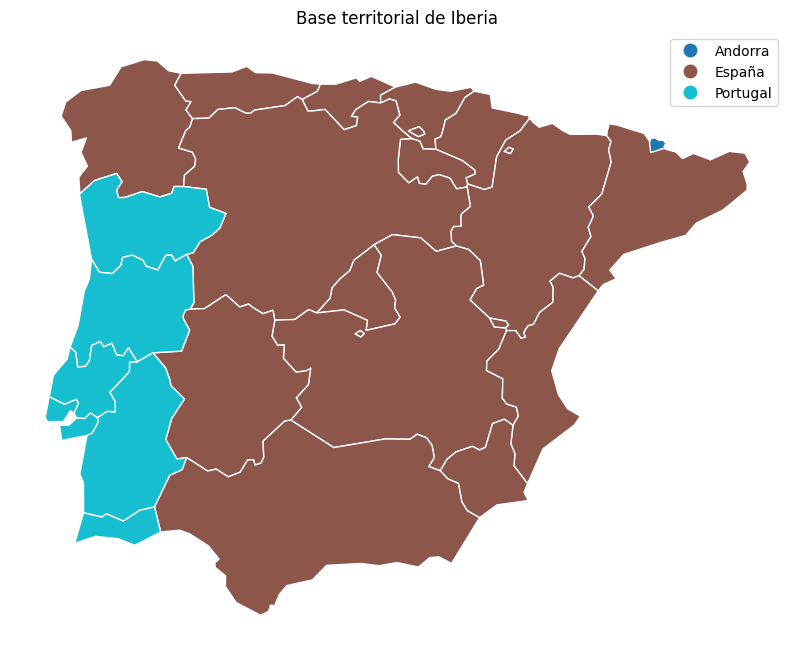

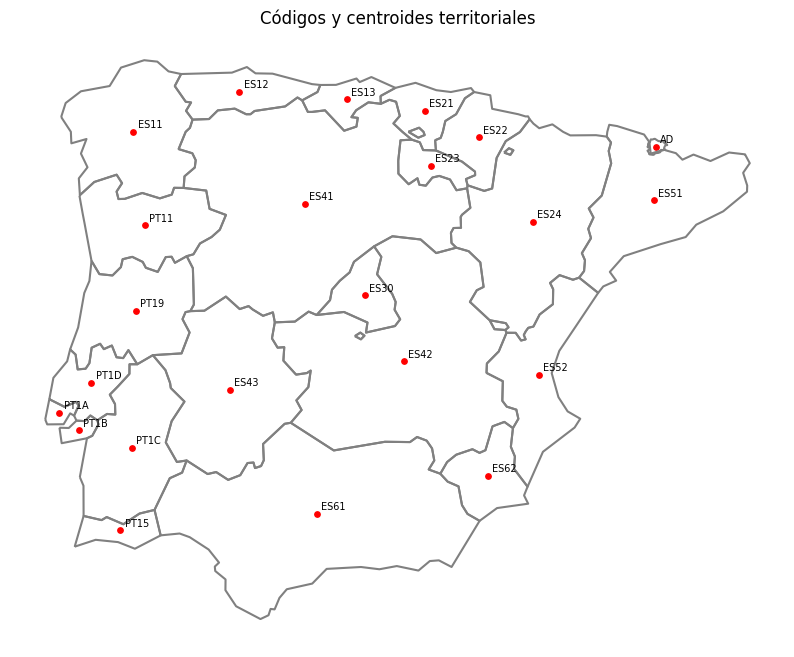

Mapas generados: 2


In [11]:
# mapas finales
ruta_mapa_base_07a = (
    FIGURAS_DIR / "figura_07A_mapa_base_geometrica_iberia_integrada.png"
)
ruta_mapa_centroides_07a = (
    FIGURAS_DIR / "figura_07A_mapa_centroides_codigo_geo.png"
)

# mapa de territorios
fig, ax = plt.subplots(figsize=(10, 8))
base_geometrica_iberia_final_06a.plot(
    ax=ax,
    column="pais",
    categorical=True,
    legend=True,
    edgecolor="white"
)
ax.set_title("Base territorial de Iberia")
ax.axis("off")
fig.savefig(
    ruta_mapa_base_07a,
    dpi=250,
    bbox_inches="tight"
)
plt.show()
plt.close(fig)

# mapa de centroides
centroides_07a = gpd.GeoDataFrame(
    base_geometrica_iberia_final_06a.drop(columns="geometry"),
    geometry=gpd.points_from_xy(
        base_geometrica_iberia_final_06a["centroide_lon"],
        base_geometrica_iberia_final_06a["centroide_lat"]
    ),
    crs=CRS_GEOGRAFICO
)
fig, ax = plt.subplots(figsize=(10, 8))
base_geometrica_iberia_final_06a.boundary.plot(
    ax=ax,
    color="gray"
)
centroides_07a.plot(
    ax=ax,
    color="red",
    markersize=15
)

for _, fila in centroides_07a.iterrows():
    ax.annotate(
        fila["codigo_geo"],
        fila.geometry.coords[0],
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=7
    )

ax.set_title("Códigos y centroides territoriales")
ax.axis("off")

fig.savefig(
    ruta_mapa_centroides_07a,
    dpi=250,
    bbox_inches="tight"
)
plt.show()
plt.close(fig)

# revisamos que se hayan guardado
rutas_figuras_07a = [
    ruta_mapa_base_07a,
    ruta_mapa_centroides_07a
]
mapas_correctos_07a = all(
    ruta.exists() and ruta.stat().st_size > 0
    for ruta in rutas_figuras_07a
)

if not mapas_correctos_07a:
    raise ValueError("Los mapas no se generaron correctamente.")

print("Mapas generados:", len(rutas_figuras_07a))


### Centroides territoriales

Para cada territorio calculamos un **centroide**, es decir, un punto que representa aproximadamente el centro de su forma.

Ese punto lo obtenemos de forma automática a partir de la geometría de la región. No corresponde a una ciudad ni indica dónde debería instalarse un CPD; solo sirve como referencia espacial.

Primero calculamos el centroide en **EPSG:3035**, un sistema de coordenadas pensado para trabajar con medidas en metros en Europa. Después lo convertimos a **EPSG:4326**, que usa las coordenadas habituales de longitud y latitud.

In [12]:
# salidas geoespaciales
base_4326_08a = base_geometrica_iberia_final_06a.to_crs(CRS_GEOGRAFICO)
base_3035_08a = base_4326_08a.to_crs(CRS_PROYECTADO)

# rutas de salida
ruta_geojson_4326_08a = (
    PROCESSED_DIR / "base_geometrica_iberia_master_notebook_09_EPSG4326.geojson"
)
ruta_gpkg_4326_08a = (
    GPKG_DIR / "base_geometrica_iberia_master_notebook_09_EPSG4326.gpkg"
)
ruta_gpkg_3035_08a = (
    GPKG_DIR / "base_geometrica_iberia_master_notebook_09_EPSG3035.gpkg"
)
ruta_csv_atributos_08a = (
    PROCESSED_DIR / "tabla_atributos_base_geometrica_iberia_master_notebook_09.csv"
)
ruta_csv_codigos_08a = (
    PROCESSED_DIR / "tabla_codigos_geo_base_geometrica_notebook_09.csv"
)

# guardamos las capas
for ruta in [
    ruta_geojson_4326_08a,
    ruta_gpkg_4326_08a,
    ruta_gpkg_3035_08a
]:
    ruta.unlink(missing_ok=True)
base_4326_08a.to_file(
    ruta_geojson_4326_08a,
    driver="GeoJSON"
)
base_4326_08a.to_file(
    ruta_gpkg_4326_08a,
    layer="base_geometrica_iberia_4326",
    driver="GPKG"
)
base_3035_08a.to_file(
    ruta_gpkg_3035_08a,
    layer="base_geometrica_iberia_3035",
    driver="GPKG"
)

# guardamos las tablas
base_4326_08a.drop(columns="geometry").to_csv(
    ruta_csv_atributos_08a,
    index=False,
    encoding="utf-8-sig"
)
columnas_08a = [
    "codigo_geo",
    "nombre_territorio",
    "codigo_pais",
    "pais",
    "tipo_unidad",
    "fuente_geometria",
    "area_km2",
    "centroide_lon",
    "centroide_lat"
]
base_4326_08a[columnas_08a].to_csv(
    ruta_csv_codigos_08a,
    index=False,
    encoding="utf-8-sig"
)

# comprobamos las salidas
rutas_08a = [
    ruta_geojson_4326_08a,
    ruta_gpkg_4326_08a,
    ruta_gpkg_3035_08a,
    ruta_csv_atributos_08a,
    ruta_csv_codigos_08a
]
archivos_correctos_08a = all(
    ruta.exists() and ruta.stat().st_size > 0
    for ruta in rutas_08a
)

duplicados_08a = base_4326_08a["codigo_geo"].duplicated().sum()

if (
    len(base_4326_08a) != 23
    or duplicados_08a != 0
    or not archivos_correctos_08a
):
    raise ValueError("Las salidas necesitan revisión.")

df_salidas_08a = pd.DataFrame({
    "archivo": [ruta.name for ruta in rutas_08a],
    "ruta": [str(ruta) for ruta in rutas_08a],
    "tamano_bytes": [ruta.stat().st_size for ruta in rutas_08a]
})
df_salidas_08a.to_csv(
    MANIFEST_DIR / "inventario_salidas_geoespaciales_notebook_09.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Archivos guardados:", len(rutas_08a))
print("Territorios:", len(base_4326_08a))
print("Duplicados:", duplicados_08a)


Archivos guardados: 5
Territorios: 23
Duplicados: 0


In [13]:
# Validación final
ruta_geojson_11a = (
    PROCESSED_DIR
    / "base_geometrica_iberia_master_notebook_09_EPSG4326.geojson"
)

capa_11a = gpd.read_file(ruta_geojson_11a)
nuts2_11a = capa_11a["tipo_unidad"].eq("nuts2_comparable").sum()
andorra_11a = capa_11a["codigo_geo"].eq("AD").sum()
duplicados_11a = capa_11a["codigo_geo"].duplicated().sum()

correcto_11a = (
    len(capa_11a) == 23
    and nuts2_11a == 22
    and andorra_11a == 1
    and duplicados_11a == 0
    and capa_11a.geometry.is_valid.all()
    and capa_11a.crs.to_epsg() == 4326
)

if not correcto_11a:
    raise ValueError("La base territorial final necesita revisión.")

pd.DataFrame([{
    "territorios": len(capa_11a),
    "nuts2": nuts2_11a,
    "andorra": andorra_11a,
    "duplicados": duplicados_11a,
    "estado": "correcto"
}]).to_csv(
    MANIFEST_DIR / "CIERRE_11A_validacion_final_notebook_09.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Territorios:", len(capa_11a))
print("NUTS 2:", nuts2_11a)
print("Andorra:", andorra_11a)
print("Duplicados:", duplicados_11a)
print("Notebook 10: compatible")

Territorios: 23
NUTS 2: 22
Andorra: 1
Duplicados: 0
Notebook 10: compatible


In [14]:
# ZIP final del Notebook 09
ruta_zip_10a = (
    Path("/kaggle/working")
    / "09_geometrias_base_territoriales_iberia_FINAL.zip"
)
ruta_zip_10a.unlink(missing_ok=True)

shutil.make_archive(
    str(ruta_zip_10a.with_suffix("")),
    "zip",
    root_dir=BASE_DIR
)

with zipfile.ZipFile(ruta_zip_10a) as archivo_zip:
    archivos_zip_10a = archivo_zip.namelist()

    if archivo_zip.testzip() is not None:
        raise ValueError("El ZIP contiene algún archivo dañado.")

print("Archivos incluidos:", len(archivos_zip_10a))
print("Tamaño ZIP MB:", round(ruta_zip_10a.stat().st_size / 1_000_000, 2))
print("ZIP final:", ruta_zip_10a)

Archivos incluidos: 35
Tamaño ZIP MB: 5.58
ZIP final: /kaggle/working/09_geometrias_base_territoriales_iberia_FINAL.zip
